<a href="https://colab.research.google.com/github/tobiartinian/Econom-a-y-Finanzas/blob/main/Clase_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree,  _tree
from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def ganancia(model, X, y, prop=1, threshold=0.025):

  class_index = np.where(model.classes_ == "BAJA+2")[0][0]
  y_hat = model.predict_proba(X)

  @np.vectorize
  def ganancia_row(predicted, actual, threshold=0.025):
    return  (predicted >= threshold) * (ganancia_acierto if actual == "BAJA+2" else -costo_estimulo)

  return ganancia_row(y_hat[:,class_index], y).sum() / prop


In [ ]:
dataset_path = '/content/drive/MyDrive/Economía y finanzas'
dataset_file = 'competencia_01.csv'

mes_train = 202104
mes_test = 202105

X = data[data['foto_mes'] == mes_train]
y = X['clase_ternaria']
X = X.drop(columns=['clase_ternaria'])

In [ ]:
X.shape

(163284, 154)

In [ ]:
len(X.columns)

154

In [ ]:
X.head()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares,Visa_fultimo_cierre,Visa_mpagado,Visa_mpagospesos,Visa_mpagosdolares,Visa_fechaalta,Visa_mconsumototal,Visa_cconsumos,Visa_cadelantosefectivo,Visa_mpagominimo
1,12662784,202104,1,0,0,62,258,51842.67,90166.46,18152.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,12899225,202104,1,0,0,73,173,-2635.56,20486.50,2628.76,...,0.0,23.0,32703.67,-33868.41,0.00,5245.0,29057.57,2.0,0.0,1665.66
13,13100047,202104,1,0,0,76,323,2161.01,62077.79,901.26,...,0.0,2.0,0.00,-34207.41,8.29,7381.0,37266.24,5.0,0.0,2439.84
19,13345490,202104,1,0,0,41,260,4083.29,22138.92,2951.25,...,0.0,9.0,0.00,-23881.06,0.00,5493.0,3379.49,3.0,0.0,2228.70
25,13615744,202104,1,0,0,63,318,3305.57,34335.17,3529.90,...,0.0,2.0,0.00,-2.36,0.00,8460.0,2.34,1.0,0.0,0.00


In [ ]:


tree_params = {
    'criterion': 'gini',
    'max_depth': 7,
    'min_samples_split': 80
}

#lista de ganancias
gan_test = []
gan_train = [] # esta no se mira NUNCA, esta para sumar dibujitos

semillas = [0] # Define 'semillas' as a list of random seeds
sss = StratifiedShuffleSplit(n_splits=31, test_size=0.3, random_state=semillas[0])

for train_index, test_index in sss.split(X, y):

  model = DecisionTreeClassifier(**tree_params)
  model.fit(X.iloc[train_index], y.iloc[train_index])

  gan_test.append(ganancia(model, X.iloc[test_index], y.iloc[test_index], prop=0.3))
  gan_train.append(ganancia(model, X.iloc[train_index], y.iloc[train_index], prop=0.7))

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


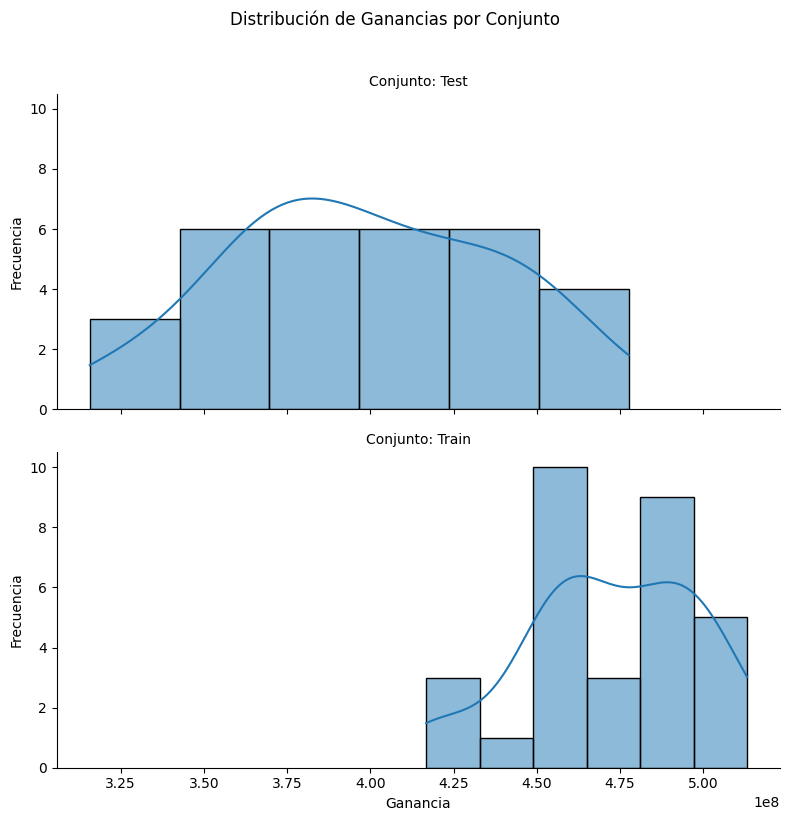

In [ ]:
# DataFrame for plotting
df_gains = pd.DataFrame({
    'Ganancia': gan_test + gan_train,
    'Conjunto': ['Test'] * len(gan_test) + ['Train'] * len(gan_train)
})

# Plot histograms using FacetGrid to stack them vertically
g = sns.FacetGrid(df_gains, row='Conjunto', aspect=2, height=4)
g.map(sns.histplot, 'Ganancia', kde=True, palette='viridis')
g.set_axis_labels('Ganancia', 'Frecuencia')
g.set_titles(row_template='Conjunto: {row_name}')
plt.suptitle('Distribución de Ganancias por Conjunto', y=1.02) # Add a main title
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

tree_params = {
    'criterion': 'gini',
    'max_depth': 5,
    'min_samples_split': 10
}

#lista de ganancias
gan_test = []
gan_train = [] # esta no se mira NUNCA, esta para sumar dibujitos

semillas = [0] # Define 'semillas' as a list of random seeds
sss = StratifiedShuffleSplit(n_splits=31, test_size=0.3, random_state=semillas[0])

for train_index, test_index in sss.split(X, y):

  model = DecisionTreeClassifier(**tree_params)
  model.fit(X.iloc[train_index], y.iloc[train_index])

  gan_test.append(ganancia(model, X.iloc[test_index], y.iloc[test_index], prop=0.3))
  gan_train.append(ganancia(model, X.iloc[train_index], y.iloc[train_index], prop=0.7))

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


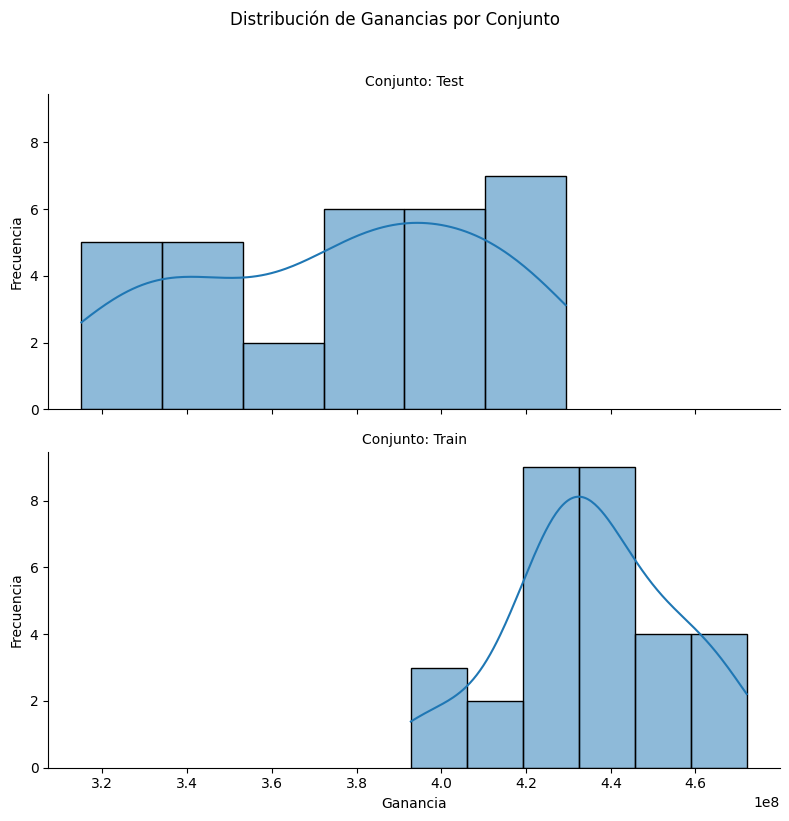

In [ ]:
# DataFrame for plotting
df_gains = pd.DataFrame({
    'Ganancia': gan_test + gan_train,
    'Conjunto': ['Test'] * len(gan_test) + ['Train'] * len(gan_train)
})

# Plot histograms using FacetGrid to stack them vertically
g = sns.FacetGrid(df_gains, row='Conjunto', aspect=2, height=4)
g.map(sns.histplot, 'Ganancia', kde=True, palette='viridis')
g.set_axis_labels('Ganancia', 'Frecuencia')
g.set_titles(row_template='Conjunto: {row_name}')
plt.suptitle('Distribución de Ganancias por Conjunto', y=1.02) # Add a main title
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [ ]:


tree_params = {
    'criterion': 'gini',
    'max_depth': 7,
    'min_samples_split': 80
}

#lista de ganancias
gan_test = []
gan_train = [] # esta no se mira NUNCA, esta para sumar dibujitos

semillas = [0] # Define 'semillas' as a list of random seeds
sss = StratifiedShuffleSplit(n_splits=31, test_size=0.3, random_state=semillas[0])

for train_index, test_index in sss.split(X, y):

  model = DecisionTreeClassifier(**tree_params)
  model.fit(X.iloc[train_index], y.iloc[train_index])

  gan_test.append(ganancia(model, X.iloc[test_index], y.iloc[test_index], prop=0.3))
  gan_train.append(ganancia(model, X.iloc[train_index], y.iloc[train_index], prop=0.7))

In [ ]:
!pip install optuna
import optuna
# Removed: from sklearn.metrics import make_scorer

# Make sure the 'ganancia' function is available in the global scope

# Removed: Custom scorer is not needed as ganancia function already takes model, X, y

def objective(trial):
    # Define the hyperparameter search space using trial.suggest_*
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 3, 15) # Explore a wider range for max_depth
    min_samples_split = trial.suggest_int('min_samples_split', 10, 500) # Explore a wider range

    model = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=semillas[0]
    )

    # Use StratifiedShuffleSplit for cross-validation within Optuna
    sss_cv = StratifiedShuffleSplit(n_splits=3, test_size=0.3, random_state=semillas[0])

    scores = []
    for train_index, test_index in sss_cv.split(X, y):
        model.fit(X.iloc[train_index], y.iloc[train_index])
        # Directly call ganancia function
        scores.append(ganancia(model, X.iloc[test_index], y.iloc[test_index], prop=0.3))

    return np.mean(scores)

# Create an Optuna study and optimize
study = optuna.create_study(direction='maximize') # We want to maximize the ganancia
study.optimize(objective, n_trials=5, show_progress_bar=True)

# Print the best trial results
print(f"\nNumber of finished trials: {len(study.trials)}")
print(f"Best trial: {study.best_trial.value}")
print("Best parameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# You can access the best model like this:
best_optuna_params = study.best_trial.params
best_optuna_model = DecisionTreeClassifier(**best_optuna_params, random_state=semillas[0])
best_optuna_model.fit(X, y) # Train the best model on the full dataset

[I 2026-08-25 00:08:36,920] A new study created in memory with name: no-name-c2915744-5a0b-448d-aac5-41c44d42dd09


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-08-25 00:09:10,397] Trial 0 finished with value: 350227777.7777778 and parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 330}. Best is trial 0 with value: 350227777.7777778.
[I 2026-08-25 00:09:26,018] Trial 1 finished with value: 364130555.5555556 and parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 64}. Best is trial 1 with value: 364130555.5555556.
[I 2026-08-25 00:09:58,912] Trial 2 finished with value: 369080555.5555556 and parameters: {'criterion': 'entropy', 'max_depth': 11, 'min_samples_split': 202}. Best is trial 2 with value: 369080555.5555556.
[I 2026-08-25 00:10:21,337] Trial 3 finished with value: 385916666.6666667 and parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 382}. Best is trial 3 with value: 385916666.6666667.
[I 2026-08-25 00:10:49,819] Trial 4 finished with value: 368988888.8888889 and parameters: {'criterion': 'gini', 'max_depth': 9, 'min_samples_split': 133}. Best is trial 3 with valu

DecisionTreeClassifier(max_depth=7, min_samples_split=382, random_state=0)

In [ ]:
import optuna.visualization as ov

# Visualize the optimization history using a contour plot
# This helps to see the relationship between hyperparameters and the objective value.
ov.plot_contour(study, params=['max_depth', 'min_samples_split'])
